In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN

In [25]:
min_max_data = pd.read_csv("full_min_max_data.csv")
tsne_results = pd.read_csv("tsne_data.csv")

In [26]:
cols_to_factor = ['credit.policy', 'not.fully.paid', 'purpose']
for col in cols_to_factor:
    min_max_data[col] = min_max_data[col].astype('category')
print(min_max_data.dtypes)

dti                   float64
fico                  float64
days.with.cr.line     float64
revol.bal             float64
revol.util            float64
inq.last.6mths        float64
delinq.2yrs           float64
pub.rec               float64
annual.inc            float64
credit.policy        category
purpose              category
not.fully.paid       category
dtype: object


# Klasterizavimas ant pilnų orginalių duomenų

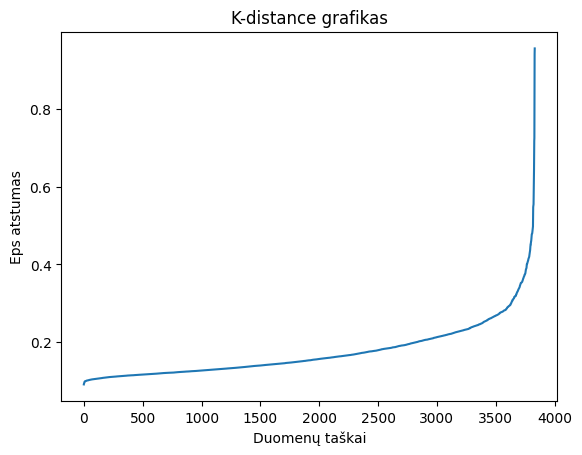

In [28]:
neighbors = NearestNeighbors(n_neighbors=18)
neighbors_fit = neighbors.fit(min_max_data.select_dtypes(include=[np.number]))
distances, indices = neighbors_fit.kneighbors(min_max_data.select_dtypes(include=[np.number]))

distances = np.sort(distances[:, 17], axis=0)
plt.plot(distances)
plt.title('K-distance grafikas')
plt.xlabel('Duomenų taškai')
plt.ylabel('Eps atstumas')
plt.show()

In [29]:
dbscan = DBSCAN(eps=0.35, min_samples=18)
clusters = dbscan.fit_predict(min_max_data.select_dtypes(include=[np.number]))

dbscan_clusters = min_max_data.copy()
dbscan_clusters['cluster'] = clusters

print(dbscan_clusters['cluster'].value_counts())

cluster
 0    3800
-1      32
Name: count, dtype: int64


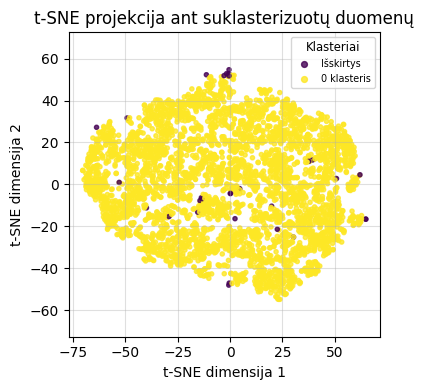

In [31]:
plt.figure(figsize=(4, 4))
scatter = plt.scatter(tsne_results.iloc[:, 0], 
                      tsne_results.iloc[:, 1], alpha=0.8, s=9, c=clusters)

plt.title("t-SNE projekcija ant suklasterizuotų duomenų")
plt.xlabel("t-SNE dimensija 1")
plt.ylabel("t-SNE dimensija 2")

handles, _ = scatter.legend_elements()
unique_labels = np.unique(clusters)
label_names = [f'{int(l)} klasteris' if l != -1 else 'Išskirtys' for l in unique_labels]
plt.legend(handles, label_names, 
           title="Klasteriai", 
           fontsize='x-small',
           title_fontsize='small',
           markerscale=0.7)
plt.grid(alpha=0.4)
plt.axis('equal')
plt.tight_layout()
plt.show()

# Klasterizavimas ant sumažintos dimensijos duomenų

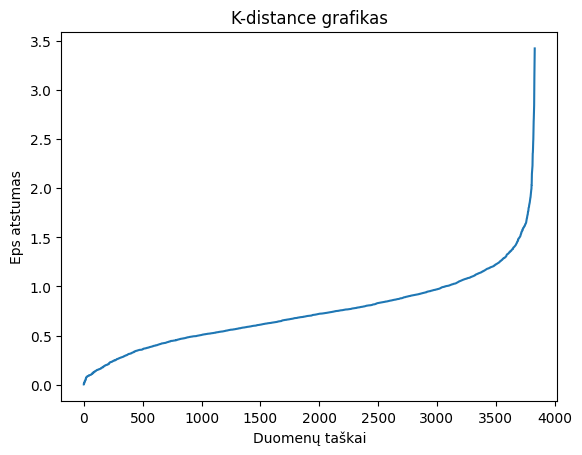

In [38]:
neighbors = NearestNeighbors(n_neighbors=4)
neighbors_fit = neighbors.fit(tsne_results)
distances, indices = neighbors_fit.kneighbors(tsne_results)

distances = np.sort(distances[:, 1], axis=0)
plt.plot(distances)
plt.title('K-distance grafikas')
plt.xlabel('Duomenų taškai')
plt.ylabel('Eps atstumas')
plt.show()

In [40]:
dbscan_tsne = DBSCAN(eps=1.5, min_samples=4)
clusters_tsne = dbscan.fit_predict(tsne_results)

dbscan_clusters_tsne = tsne_results.copy()
dbscan_clusters_tsne['cluster'] = clusters_tsne

print(dbscan_clusters_tsne['cluster'].value_counts())

cluster
-1      494
 84      99
 14      89
 46      73
 12      67
       ... 
 211      3
 209      3
 235      3
 223      3
 236      3
Name: count, Length: 241, dtype: int64


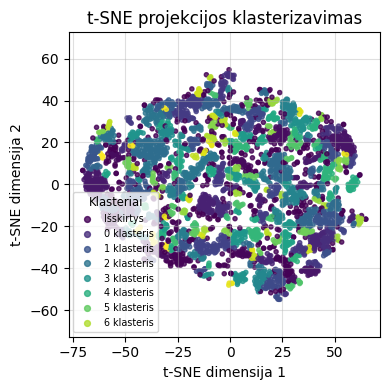

In [42]:
plt.figure(figsize=(4, 4))
scatter = plt.scatter(dbscan_clusters_tsne.iloc[:, 0], 
                      dbscan_clusters_tsne.iloc[:, 1], alpha=0.8, s=9, c=clusters)

plt.title("t-SNE projekcijos klasterizavimas")
plt.xlabel("t-SNE dimensija 1")
plt.ylabel("t-SNE dimensija 2")

handles, _ = scatter.legend_elements()
unique_labels = np.unique(clusters)
label_names = [f'{int(l)} klasteris' if l != -1 else 'Išskirtys' for l in unique_labels]
plt.legend(handles, label_names, 
           title="Klasteriai", 
           fontsize='x-small',
           title_fontsize='small',
           markerscale=0.7)
plt.grid(alpha=0.4)
plt.axis('equal')
plt.tight_layout()
plt.show()